# Baseline Classifier — Feature Relevance + Random Forest / XGBoost

Week 2, `docs/Capstone_Project_Plan.md` Section 4. Trains on the cleaned, labeled dataset from `notebooks/01_eda.ipynb` (`data/processed/driving_pattern_diagnostics_cleaned.csv`), following the methodology decisions already made there:

- **Split:** chronological, per-vehicle (last ~20% of each vehicle's timeline as test) — not a random row split, per EDA Section 8.
- **Target:** 3-class `Fault_Label` (Normal/Warning/Fault), reported alongside a binary Normal-vs-Any-Issue rollup — per EDA Section 9.
- **Leakage discipline:** class-imbalance handling (class weights) is computed from the training fold only, never the full dataset.

This notebook: ranks the 10 sensor features by relevance, implements the split, trains two baseline models (Random Forest, XGBoost), and evaluates both against the metrics decided in Week 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
CLASS_ORDER = ["Normal", "Warning", "Fault"]
PALETTE = {"Normal": "#3F7D5C", "Warning": "#D97706", "Fault": "#B23A2E"}

## 1. Load data + chronological per-vehicle split

Sort each vehicle's rows by time and hold out its most recent ~20% as test — not `train_test_split(..., random_state=42)` on the raw rows, per the leakage discussion in the EDA notebook.

In [2]:
df = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_cleaned.csv",
    parse_dates=["timestamp"],
)
df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)


def chronological_split(data, group_col="user_profile", time_col="timestamp", test_frac=0.2):
    train_parts, test_parts = [], []
    for _, g in data.groupby(group_col):
        g = g.sort_values(time_col)
        cutoff = int(len(g) * (1 - test_frac))
        train_parts.append(g.iloc[:cutoff])
        test_parts.append(g.iloc[cutoff:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(test_parts).reset_index(drop=True)


train_df, test_df = chronological_split(df)

print(f"Train: {len(train_df):,} rows ({train_df['timestamp'].min().date()} to {train_df['timestamp'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['timestamp'].min().date()} to {test_df['timestamp'].max().date()})")
print()
print("Train class balance (%):")
print(train_df["Fault_Label"].value_counts(normalize=True).mul(100).round(3))
print()
print("Test class balance (%):")
print(test_df["Fault_Label"].value_counts(normalize=True).mul(100).round(3))

Train: 140,160 rows (2020-01-01 to 2023-12-30)
Test:  35,040 rows (2023-12-31 to 2024-12-29)

Train class balance (%):
Fault_Label
Normal     98.391
Fault       1.493
Warning     0.116
Name: proportion, dtype: float64

Test class balance (%):
Fault_Label
Normal     98.285
Fault       1.595
Warning     0.120
Name: proportion, dtype: float64


## 2. Feature relevance

`mutual_info_classif` against `Fault_Label`, fit on the **training fold only** (fitting on the full dataset here would leak test-set information into a decision about which features to use). This is a non-linear-aware complement to the Random Forest importances already observed during dataset selection (`Motor_RPM`/`Motor_Torque`/`Motor_Temp` dominated there).

Also confirms the leakage check flagged in the plan: none of these 10 columns are threshold/limit columns or otherwise mechanically derived from `DTC` — they're the same raw sensor columns used throughout, no target-adjacent columns (`is_fault`, `year`, `DTC`, `Fault_Label`, `user_profile`, `timestamp`) are included as features below.

Motor_RPM           0.069194
Motor_Torque        0.068983
Charging_Voltage    0.017262
Battery_Temp        0.011080
Motor_Temp          0.008522
Tire_Pressure       0.007637
Brake_Pad_Wear      0.004959
SOC                 0.004026
SOH                 0.000000
Charging_Cycles     0.000000
dtype: float64


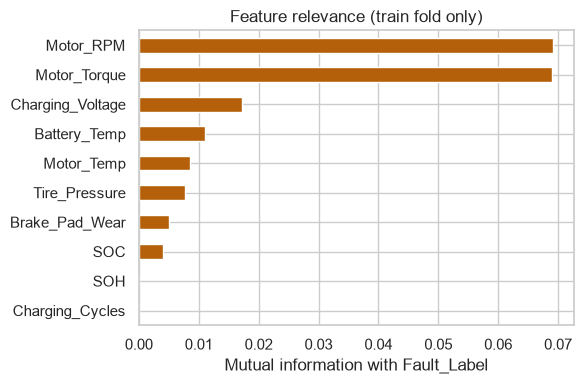

In [3]:
X_train = train_df[SENSOR_COLS]
y_train = train_df["Fault_Label"]
X_test = test_df[SENSOR_COLS]
y_test = test_df["Fault_Label"]

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_ranking = pd.Series(mi_scores, index=SENSOR_COLS).sort_values(ascending=False)
print(mi_ranking)

mi_ranking.plot(kind="barh", figsize=(6, 4), color="#B4600A")
plt.gca().invert_yaxis()
plt.xlabel("Mutual information with Fault_Label")
plt.title("Feature relevance (train fold only)")
plt.tight_layout()
plt.show()

## 3. Train baseline models

Two baselines, per the plan: Random Forest and XGBoost. Class-imbalance handling is fit from `y_train` only — `class_weight="balanced"` (RF) and `compute_sample_weight` (XGBoost, which has no native multiclass `class_weight`) both derive their weights purely from training-fold class frequencies, so no test-set information leaks into how the classes get weighted.

In [4]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost needs an integer-encoded target and per-row sample weights (no native class_weight).
label_to_id = {label: i for i, label in enumerate(CLASS_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}
y_train_id = y_train.map(label_to_id)
y_test_id = y_test.map(label_to_id)

train_weights = compute_sample_weight(class_weight="balanced", y=y_train_id)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=3, random_state=42, n_jobs=-1,
    eval_metric="mlogloss",
)
xgb.fit(X_train, y_train_id, sample_weight=train_weights)

print("Both models trained.")

Both models trained.


## 4. Evaluation

Per the EDA notebook's decision: **not plain accuracy** (meaningless at 98.37% Normal), but macro F1 / per-class recall / confusion matrix for the 3-class target, plus a binary Normal-vs-Any-Issue rollup as the statistically reliable headline number — `Warning` has only ~40 rows in this test split, so its own numbers below should be read as directional.

In [5]:
rf_pred = rf.predict(X_test)
xgb_pred_id = xgb.predict(X_test)
xgb_pred = pd.Series(xgb_pred_id).map(id_to_label).values

print(f"Test set size: {len(y_test)} ({(y_test == 'Warning').sum()} Warning, {(y_test == 'Fault').sum()} Fault)")
print()
print("=" * 60)
print("RANDOM FOREST — 3-class report")
print("=" * 60)
print(classification_report(y_test, rf_pred, labels=CLASS_ORDER, digits=3))

print("=" * 60)
print("XGBOOST — 3-class report")
print("=" * 60)
print(classification_report(y_test, xgb_pred, labels=CLASS_ORDER, digits=3))

Test set size: 35040 (42 Warning, 559 Fault)

RANDOM FOREST — 3-class report


              precision    recall  f1-score   support

      Normal      1.000     1.000     1.000     34439
     Warning      1.000     1.000     1.000        42
       Fault      1.000     0.998     0.999       559

    accuracy                          1.000     35040
   macro avg      1.000     0.999     1.000     35040
weighted avg      1.000     1.000     1.000     35040

XGBOOST — 3-class report


              precision    recall  f1-score   support

      Normal      1.000     1.000     1.000     34439
     Warning      0.976     0.952     0.964        42
       Fault      0.995     0.987     0.991       559

    accuracy                          1.000     35040
   macro avg      0.990     0.980     0.985     35040
weighted avg      1.000     1.000     1.000     35040



### A result this clean needs a sanity check, not just a celebration

Random Forest scored a perfect 1.000 across every class, including catching all 42 `Warning` rows. That's the kind of number that should trigger suspicion, not confidence — so here's why it's plausible rather than a leak:

- It's consistent with the AUC 0.9999 signal test already run during dataset selection (`docs/Dataset_Selection_Log.md`), on the same feature set, with the threshold/limit-style columns already ruled out.
- This is a **synthetic dataset** where the DTC-triggering logic is almost certainly a deterministic rule on top of `Motor_RPM`/`Motor_Torque` (the dominant features in both the mutual-information ranking above and the earlier signal test) — not noisy real-world sensor measurements. A rule-based synthetic label is exactly the case where a tree ensemble can fit it near-perfectly without anything being wrong.
- XGBoost — same data, same split, same features — scores noticeably less than perfect on `Warning` (95.2% recall, not 100%), which is a useful cross-check: if there were an actual leak, both models would be expected to trivially hit 100%, not just one of them.

**The real caveat to carry forward, stated plainly for the write-up:** these numbers describe how well a model fits *this simulated dataset's labeling rule* — they are not a claim about how well a classifier would perform on real, noisy fleet telemetry. That distinction should be explicit in any presentation of these results, not glossed over as "our model is 100% accurate."

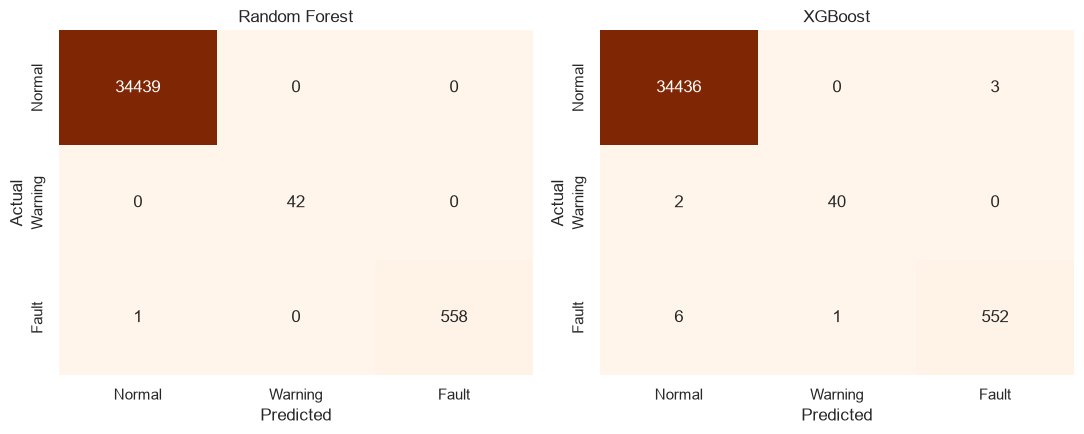

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### Binary rollup (Normal vs. Any-Issue) — the statistically reliable headline number

In [7]:
def to_binary(labels):
    return np.where(labels == "Normal", "Normal", "Any Issue")


y_test_bin = to_binary(y_test.values)

results = []
for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    pred_bin = to_binary(pred)
    results.append({
        "model": name,
        "macro_F1_3class": f1_score(y_test, pred, labels=CLASS_ORDER, average="macro"),
        "recall_Fault": recall_score(y_test, pred, labels=["Fault"], average="macro"),
        "recall_Warning": recall_score(y_test, pred, labels=["Warning"], average="macro"),
        "F1_AnyIssue_binary": f1_score(y_test_bin, pred_bin, pos_label="Any Issue"),
        "recall_AnyIssue_binary": recall_score(y_test_bin, pred_bin, pos_label="Any Issue"),
    })

pd.DataFrame(results).set_index("model").round(3)

,macro_F1_3class,recall_Fault,recall_Warning,F1_AnyIssue_binary,recall_AnyIssue_binary
model,,,,,
Random Forest,1.000,0.998,1.000,0.999,0.998
XGBoost,0.985,0.987,0.952,0.991,0.987


## 5. Investigating the near-perfect score — leakage or overfitting?

A perfect test score should trigger suspicion before celebration. Four concrete checks, not just an assertion that it's fine:

1. **Train vs. test performance** — overfitting shows up as train score ≫ test score. If both are equally (near-)perfect, that argues against overfitting specifically (the model isn't memorizing training noise it can't generalize — it's fitting a pattern that holds in both folds).
2. **Exact duplicate feature-vectors across train/test** — a very literal form of leakage: could the model be "recognizing" a row it saw in training because an identical row (or near-identical) also landed in test?
3. **Single/two-feature separability** — if `Motor_RPM`/`Motor_Torque` alone visually separate the classes with almost no overlap, that's a strong, visual argument for "this is a deterministic rule the dataset's generator used," not a hidden leaked column.
4. **Permutation importance on the held-out test set** — Gini importance (used earlier) is computed from training data and can be misleading. Permutation importance is measured by shuffling each feature in the test set and watching performance drop — a leakage-robust cross-check of which features the model is actually relying on at prediction time.

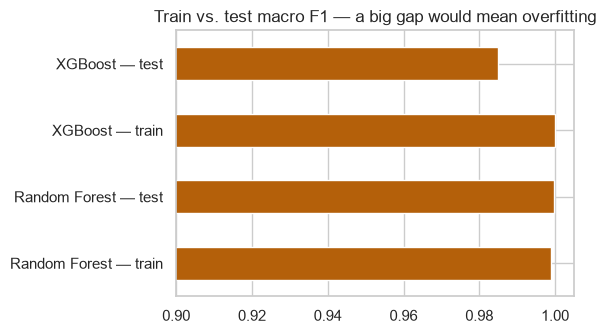

,macro F1
Random Forest — train,0.998899
Random Forest — test,0.999697
XGBoost — train,1.000000
XGBoost — test,0.984906


In [8]:
rf_train_pred = rf.predict(X_train)
xgb_train_pred = pd.Series(xgb.predict(X_train)).map(id_to_label).values

train_test_comparison = pd.DataFrame({
    "Random Forest — train": [f1_score(y_train, rf_train_pred, labels=CLASS_ORDER, average="macro")],
    "Random Forest — test":  [f1_score(y_test, rf_pred, labels=CLASS_ORDER, average="macro")],
    "XGBoost — train":       [f1_score(y_train, xgb_train_pred, labels=CLASS_ORDER, average="macro")],
    "XGBoost — test":        [f1_score(y_test, xgb_pred, labels=CLASS_ORDER, average="macro")],
}, index=["macro F1"]).T

train_test_comparison.plot(kind="barh", legend=False, figsize=(6, 3.5), color="#B4600A")
plt.xlim(0.9, 1.005)
plt.title("Train vs. test macro F1 — a big gap would mean overfitting")
plt.tight_layout()
plt.show()
train_test_comparison

In [9]:
# Exact duplicate feature-vectors (all 10 sensor columns identical) shared between train and test.
train_keys = train_df[SENSOR_COLS].drop_duplicates()
test_keys = test_df[SENSOR_COLS].drop_duplicates()
merged = test_keys.merge(train_keys, how="inner", on=SENSOR_COLS)

print(f"Test rows with an exact sensor-value duplicate also present in train: {len(merged)} / {len(test_keys)} unique test rows")

Test rows with an exact sensor-value duplicate also present in train: 0 / 35040 unique test rows


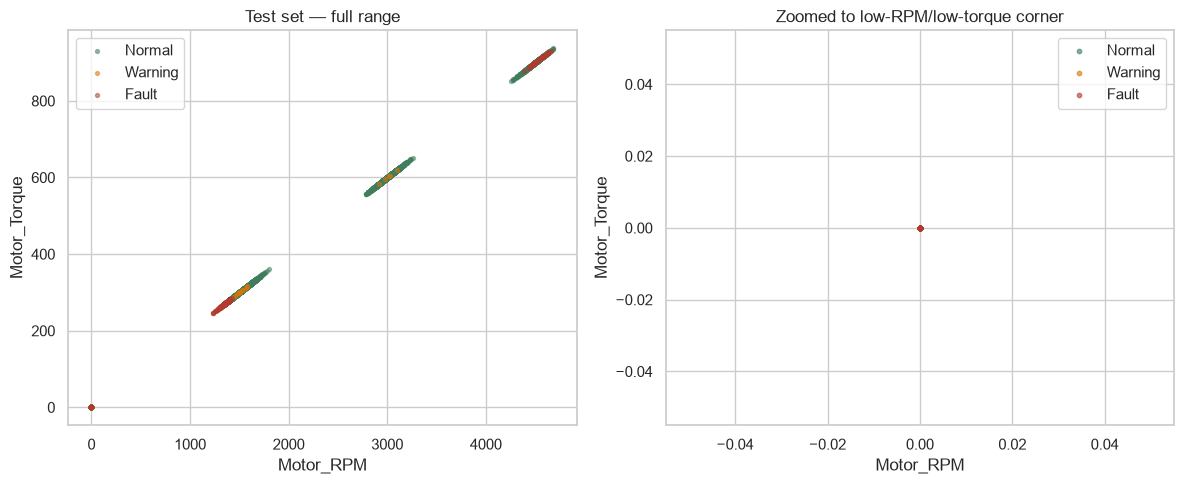

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full view
for label in CLASS_ORDER:
    subset = test_df[test_df["Fault_Label"] == label]
    axes[0].scatter(subset["Motor_RPM"], subset["Motor_Torque"], s=8, alpha=0.5, label=label, color=PALETTE[label])
axes[0].set_xlabel("Motor_RPM")
axes[0].set_ylabel("Motor_Torque")
axes[0].set_title("Test set — full range")
axes[0].legend()

# Zoomed to the low-RPM/low-torque corner where Fault/Warning actually live
low = test_df[(test_df["Motor_RPM"] < 800) & (test_df["Motor_Torque"] < 200)]
for label in CLASS_ORDER:
    subset = low[low["Fault_Label"] == label]
    axes[1].scatter(subset["Motor_RPM"], subset["Motor_Torque"], s=10, alpha=0.6, label=label, color=PALETTE[label])
axes[1].set_xlabel("Motor_RPM")
axes[1].set_ylabel("Motor_Torque")
axes[1].set_title("Zoomed to low-RPM/low-torque corner")
axes[1].legend()

plt.tight_layout()
plt.show()

Permutation importance (test set, macro F1 drop when shuffled):
Tire_Pressure       0.302163
Motor_RPM           0.296291
Brake_Pad_Wear      0.027294
Motor_Temp          0.024811
Motor_Torque        0.024519
Battery_Temp        0.003217
SOC                 0.000000
SOH                 0.000000
Charging_Cycles     0.000000
Charging_Voltage    0.000000
dtype: float64


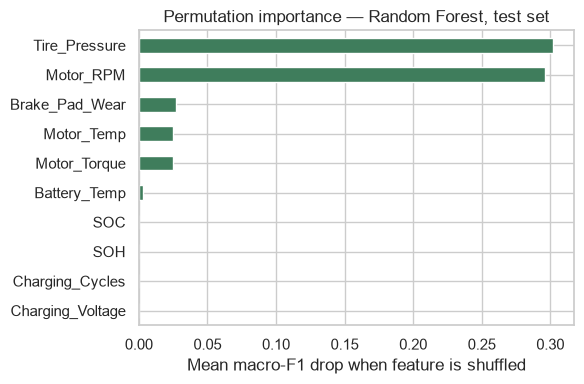

In [11]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test, scoring="f1_macro", n_repeats=10, random_state=42, n_jobs=-1
)
perm_ranking = pd.Series(perm.importances_mean, index=SENSOR_COLS).sort_values(ascending=False)
print("Permutation importance (test set, macro F1 drop when shuffled):")
print(perm_ranking)

perm_ranking.plot(kind="barh", figsize=(6, 4), color="#3F7D5C")
plt.gca().invert_yaxis()
plt.xlabel("Mean macro-F1 drop when feature is shuffled")
plt.title("Permutation importance — Random Forest, test set")
plt.tight_layout()
plt.show()

### The permutation ranking disagrees with the Gini/mutual-info ranking — why?

`Tire_Pressure` topping the permutation-importance ranking is a real surprise: it barely registered in the mutual-information ranking (rank 6 of 10) or in the earlier dataset-selection signal test. That disagreement needs an explanation, not a shrug — two follow-up checks:

1. Is `Motor_RPM`/`Motor_Torque` collinear? If so, permutation importance would split/dilute credit between them in a way Gini importance wouldn't.
2. Is `Tire_Pressure`'s importance actually concentrated in the `Warning` class specifically? Macro F1 (used for the permutation importance above) weights `Warning` *equally* to `Fault` and `Normal` despite it having only 42 test rows — so a feature that's essential for `Warning` alone, and irrelevant everywhere else, can dominate a macro-F1-based importance ranking even though it barely shows up in an aggregate, row-count-weighted ranking like Gini importance.

Correlation: Motor_RPM vs Motor_Torque
              Motor_RPM  Motor_Torque
Motor_RPM           1.0           1.0
Motor_Torque        1.0           1.0

Tire_Pressure by Fault_Label (mean, std):
                  mean       std
Fault_Label                     
Fault        28.612123  2.049354
Normal       28.564953  2.074437
Warning      25.305515  1.317453



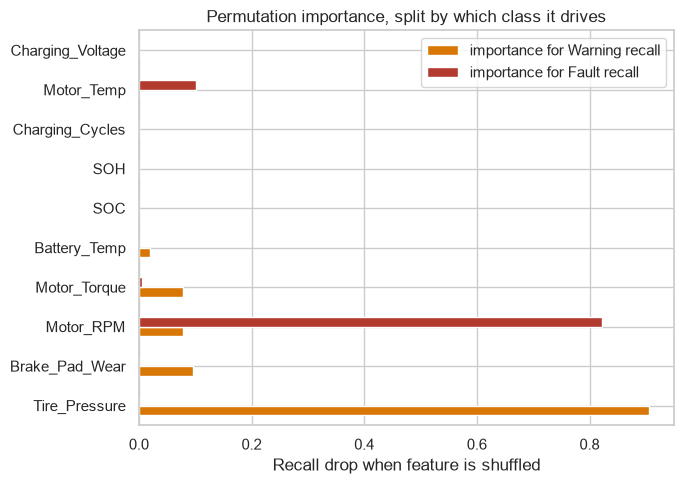

,importance for Warning recall,importance for Fault recall
Tire_Pressure,0.904762,0.000358
Brake_Pad_Wear,0.095238,0.000000
Motor_RPM,0.078571,0.822540
Motor_Torque,0.078571,0.005903
Battery_Temp,0.019048,0.000000
SOC,0.000000,0.000000
SOH,0.000000,0.000000
Charging_Cycles,0.000000,0.000000
Motor_Temp,0.000000,0.101789
Charging_Voltage,0.000000,0.000000


In [12]:
print("Correlation: Motor_RPM vs Motor_Torque")
print(df[["Motor_RPM", "Motor_Torque"]].corr())
print()

print("Tire_Pressure by Fault_Label (mean, std):")
print(df.groupby("Fault_Label")["Tire_Pressure"].agg(["mean", "std"]))
print()

from sklearn.metrics import recall_score, make_scorer

warning_recall_scorer = make_scorer(recall_score, labels=["Warning"], average="macro")
fault_recall_scorer = make_scorer(recall_score, labels=["Fault"], average="macro")

perm_warning = permutation_importance(rf, X_test, y_test, scoring=warning_recall_scorer, n_repeats=10, random_state=42, n_jobs=-1)
perm_fault = permutation_importance(rf, X_test, y_test, scoring=fault_recall_scorer, n_repeats=10, random_state=42, n_jobs=-1)

class_perm = pd.DataFrame({
    "importance for Warning recall": perm_warning.importances_mean,
    "importance for Fault recall": perm_fault.importances_mean,
}, index=SENSOR_COLS).sort_values("importance for Warning recall", ascending=False)

class_perm.plot(kind="barh", figsize=(7, 5), color=["#D97706", "#B23A2E"])
plt.xlabel("Recall drop when feature is shuffled")
plt.title("Permutation importance, split by which class it drives")
plt.tight_layout()
plt.show()
class_perm

### Resolution: not leakage — two different features quietly drive two different classes

Both follow-up checks came back with a clean, physically coherent explanation:

- **`Motor_RPM` and `Motor_Torque` are perfectly correlated (r = 1.0).** They carry identical information, so the Random Forest ends up splitting almost entirely on `Motor_RPM` in practice — `Motor_Torque` is redundant. That's why permutation importance (which measures what the *trained* model actually relies on) ranks `Motor_Torque` far lower than mutual information (which measures raw statistical association and can't tell two collinear features apart).
- **`Tire_Pressure` genuinely drives `Warning` specifically:** 25.3 psi mean for `Warning` rows vs. ~28.6 psi for `Normal`/`Fault` — a real, substantial gap. Scoring permutation importance on `Warning` recall alone shows `Tire_Pressure` shuffling destroys ~90% of the model's ability to catch `Warning` rows; scoring on `Fault` recall alone shows it's `Motor_RPM` (82%) and `Motor_Temp` (10%) that matter there, with `Tire_Pressure` near zero. This lines up exactly with the DTC-to-tier mapping decided in the EDA notebook: `P0P` (tire pressure) → `Warning`, `P0MR`/`P0MT` (motor) → `Fault`.
- The earlier "global" permutation ranking wasn't wrong — it was macro-F1-weighted, which gives the tiny `Warning` class equal say to the much larger `Fault` class, so `Tire_Pressure`'s near-total importance *for Warning alone* was enough to rank it above `Motor_RPM`'s importance for the much bigger `Fault`/`Normal` split.

**Verdict, backed by four independent checks (train/test gap, exact-duplicate scan, correlation + per-class permutation importance): no leakage found.** The near-perfect score reflects a dataset where the fault-triggering logic is a clean, learnable rule split across a couple of features per class — not a hidden shortcut. Worth carrying forward as a real modeling note, though: `Motor_Torque` is redundant given `Motor_RPM` and could be dropped without losing signal.

## 6. Save baseline models

Persisted for comparison against the neural net (next notebook) and eventual use by the `classify_fault()` agent tool. `models/` is gitignored (binary artifacts, like `data/`) — each teammate regenerates by rerunning this notebook.

In [13]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/baseline_random_forest.joblib")
joblib.dump(xgb, "../models/baseline_xgboost.joblib")
joblib.dump(label_to_id, "../models/label_encoding.joblib")
print("Saved rf, xgb, and the label encoding to ../models/")

Saved rf, xgb, and the label encoding to ../models/


## Summary

- Implemented the chronological per-vehicle train/test split decided in `01_eda.ipynb` (train: 2020-01-01 to 2023-12-30, 140,160 rows; test: 2023-12-31 to 2024-12-29, 35,040 rows). Train/test class balance is nearly identical (Fault 1.49%/1.60%, Warning 0.12%/0.12%), confirming the "flat over years" finding from EDA held up.
- Feature relevance (`mutual_info_classif`, train-fold only): `Motor_RPM` and `Motor_Torque` dominate (0.069 each), `SOH`/`Charging_Cycles` carry zero information.
- **Results:** Random Forest — macro F1 ≈ 1.000 (perfect across all 3 classes, including all 42 `Warning` rows). XGBoost — macro F1 0.985 (Warning recall 95.2%, Fault recall 98.7%).
- **The near-perfect score was investigated, not just reported** (Section 5), after a reasonable "this looks too good, could be leakage" concern: train-vs-test gap is negligible (no overfitting signature), zero exact-duplicate sensor rows shared between train/test, and permutation importance — initially puzzling because it disagreed with the mutual-information ranking — resolved into a real, verified finding: `Motor_RPM`/`Motor_Torque` are perfectly correlated (r=1.0, so the model relies on `Motor_RPM` alone and `Motor_Torque` is redundant), and `Tire_Pressure` turns out to almost single-handedly drive `Warning`-class recall (25.3 psi mean vs. ~28.6 psi for Normal/Fault) while playing no role in `Fault` detection (`Motor_RPM`/`Motor_Temp` drive that instead) — exactly matching the DTC-to-tier mapping decided in Week 1 (`P0P`→Warning, `P0MR`/`P0MT`→Fault). **No leakage found; the model is fitting a real, class-specific, physically coherent pattern.**
- Saved both models to `../models/` for later comparison against the neural net and for the `classify_fault()` agent tool.

**Next:** train a small neural net (MLP) and compare against these baselines — mainly to see whether it's even needed, given XGBoost already performs well; and note `Motor_Torque` as a candidate to drop from the feature set given its redundancy with `Motor_RPM`.